In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
df = pd.read_csv('ames.csv')

In [ ]:
#Mutual information is a lot like correlation
#Useful at the start of feature development

In [5]:
df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YearSold,SaleType,SaleCondition,SalePrice
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141.0,31770.0,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,0.0,No_Pool,No_Fence,NaN,0.0,5,2010,WD,Normal,215000
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80.0,11622.0,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,...,0.0,No_Pool,Minimum_Privacy,NaN,0.0,6,2010,WD,Normal,105000
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81.0,14267.0,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,0.0,No_Pool,No_Fence,Gar2,12500.0,6,2010,WD,Normal,172000


In [8]:
X = df.copy()
y = X.pop('SalePrice')

In [10]:
#Label encoding for categoricals
for colname in X.select_dtypes('object'):
    X[colname], _ = X[colname].factorize()

discrete_features = X.dtypes == int

In [11]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores[::3]  # show a few features with their MI scores

OverallQual         0.582358
YearBuilt           0.438426
GarageCars          0.393077
ExterQual           0.333133
MSSubClass          0.293081
Foundation          0.236257
FireplaceQu         0.224775
BsmtFinSF1          0.183354
OpenPorchSF         0.177335
HeatingQC           0.170704
OverallCond         0.131178
BsmtUnfSF           0.116987
GarageQual          0.095624
HouseStyle          0.090040
PavedDrive          0.073799
Electrical          0.055634
BldgType            0.048930
EnclosedPorch       0.044386
RoofStyle           0.031890
Alley               0.024678
KitchenAbvGr        0.018277
LowQualFinSF        0.009206
Functional          0.007451
MiscFeature         0.003236
LandSlope           0.000433
Threeseasonporch    0.000000
Name: MI Scores, dtype: float64

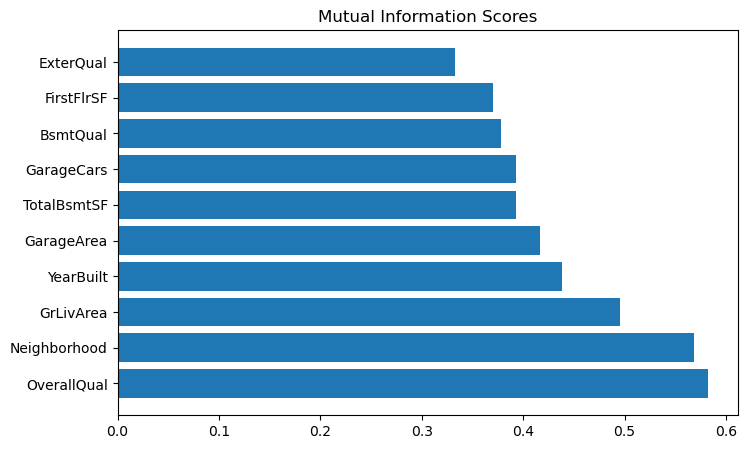

In [14]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=False).head(10)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

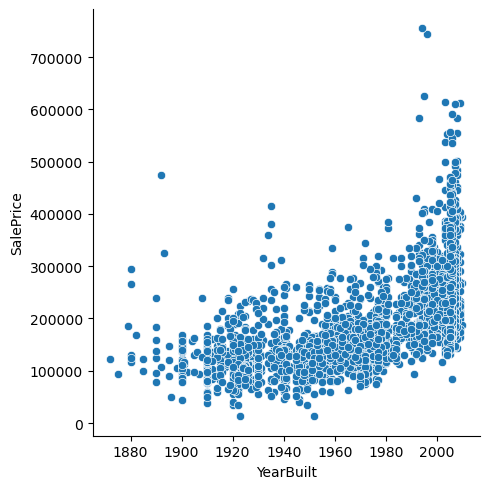

In [16]:
sns.relplot(x='YearBuilt',y='SalePrice',data=df)

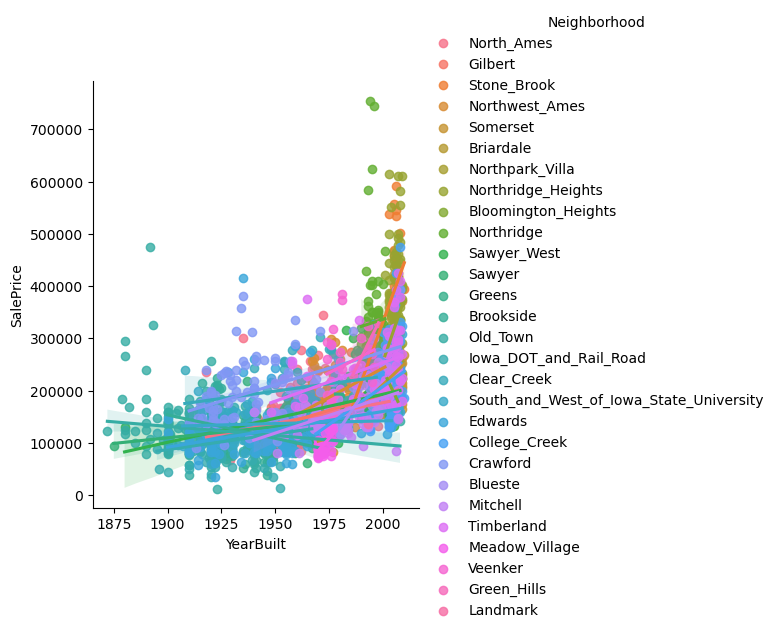

In [21]:
sns.lmplot(x='YearBuilt',y='SalePrice',hue='Neighborhood',data=df);

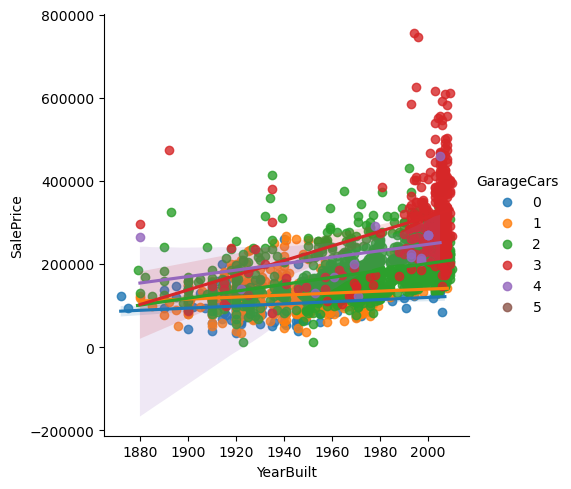

In [22]:
sns.lmplot(x='YearBuilt',y='SalePrice',hue='GarageCars',data=df);